# TimesFM 2.5 Script

In [1]:
# Load libraries
import numpy as np
import pandas as pd
import torch
import timesfm
import matplotlib.pyplot as plt
import seaborn as sns

import json
from datetime import datetime
import random
import os

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

import warnings
warnings.filterwarnings("ignore")

from utils_folder.data_util import *
from utils_folder.timesfm_25_util import *
from utils_folder.plot_util import *

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Critical for CuDNN reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Create folder to store results
BASE_RESULTS_DIR = "results"
SUBFOLDERS = {
    "plain_prediction": "plain_prediction",
    "seasonal_decomposition": "seasonal_decomposition"
}
os.makedirs(BASE_RESULTS_DIR, exist_ok=True)

# Create subdirectories
RESULTS_DIRS = {}
for key, folder_name in SUBFOLDERS.items():
    path = os.path.join(BASE_RESULTS_DIR, folder_name)
    os.makedirs(path, exist_ok=True)
    RESULTS_DIRS[key] = path

c:\Users\casas\Desktop\Universidad\Master\Trabajo Fin de Master\Code\timesfm_LOCAL_ARCHIVE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Example datasets

In [3]:
# Define hyperparameters 
context_length = [256]
horizon_length = [1, 4, 8, 16, 24, 32]
max_h = max(horizon_length)
freq_type = 0
is_real_data = [False, True]


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


for val in is_real_data:
    results = {
        "freq_type": freq_type,
        "is_real_data": val,
        "experiments": []
    }

    for c in context_length:
        for h in horizon_length:
            print(f"Evaluating Case: Context={c}, Horizon={h}")
            if val:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_real_data(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type
                )
            else:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_data_synthetic(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type
                )

            metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler)

            results["experiments"].append({
                "context_length": c,
                "horizon": h,
                "metrics": metrics
            })

    date_str = datetime.now().strftime("%Y-%m-%d")
    if val:
        file_name = f"timesfm2_5_results_{date_str}.json"
    else:
        file_name = f"synth_timesfm2_5_results_{date_str}.json"

    output_dir = RESULTS_DIRS["plain_prediction"]
    file_path = os.path.join(output_dir, file_name)

    with open(file_path, "w") as f:
        json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=256, Horizon=1
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1144
Inference time: 78.9672 seconds

Evaluating Case: Context=256, Horizon=4
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1142
Inference time: 86.5317 seconds

Evaluating Case: Context=256, Horizon=8
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1173
Inference time: 78.2822 seconds

Evaluating Case: Context=256, Horizon=16
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1248
Inference time: 79.7571 seconds

Evaluating Case: Context=256, Horizon=24
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1172
Inference time: 77.6856 seconds

Evaluating Case:

[*********************100%***********************]  1 of 1 completed


Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0


[*********************100%***********************]  1 of 1 completed

Validation Metrics
RMSE: 0.8876
Inference time: 72.7991 seconds

Evaluating Case: Context=256, Horizon=4
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0


...


[*********************100%***********************]  1 of 1 completed

Validation Metrics
RMSE: 3.8091
Inference time: 82.6443 seconds

Evaluating Case: Context=256, Horizon=24
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0



[*********************100%***********************]  1 of 1 completed

Validation Metrics
RMSE: 5.0586
Inference time: 63.5082 seconds

Evaluating Case: Context=256, Horizon=32
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0


Validation Metrics
RMSE: 6.2340
Inference time: 83.6671 seconds



### Series decomposition
In the case of the synthetic dataset, the model is run once more over different seasonal decompositions, given the nature of the data. In particular, two approaches will be tested:
* Series is decomposed, extracting the seasonality and computing the predictions over the remaining series.
  * Period is detected automatically given the Autocorrelation Function (ACF).
  * A value of 300 (highest period out of the three sine waves) is predefined.
* Series is decomposed, extracting both seasonality and trend detected and computing the predictions over the remaining noise.
#### Seasonal decomposition
##### Automatic period detection

In [4]:
# Define hyperparameters 
context_length = [256]
horizon_length = [1, 4, 8, 16, 24, 32]
max_h = max(horizon_length)
freq_type = 0
is_real_data = [False]
decompose_method = "seasonal"


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


for val in is_real_data:
    results = {
        "freq_type": freq_type,
        "is_real_data": val,
        "experiments": []
    }

    for c in context_length:
        for h in horizon_length:
            print(f"Evaluating Case: Context={c}, Horizon={h}")
            if val:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_real_data(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type,
                    decompose=decompose_method,
                    period="auto"
                )
            else:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_data_synthetic(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type,
                    decompose=decompose_method,
                    period="auto"
                )

            metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler, seasonal_comp=seasonal_comp, train_size=train_size)

            results["experiments"].append({
                "context_length": c,
                "horizon": h,
                "metrics": metrics
            })

    date_str = datetime.now().strftime("%Y-%m-%d")
    if val:
        file_name = f"{decompose_method}_metrics_results_{date_str}.json"
    else:
        file_name = f"{decompose_method}_synth_metrics_results_{date_str}.json"

    output_dir = RESULTS_DIRS["seasonal_decomposition"]
    file_path = os.path.join(output_dir, file_name)

    with open(file_path, "w") as f:
        json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=256, Horizon=1
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1348
Inference time: 58.3366 seconds

Evaluating Case: Context=256, Horizon=4
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1337
Inference time: 83.0141 seconds

Evaluating Case: Context=256, Horizon=8
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1360
Inference time: 59.7765 seconds

Evaluating Case: Context=256, Horizon=16
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1448
Inference time: 78.5652 seconds

Evaluating Case: Context=256, Horizon=24
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using

##### Predefined period

In [13]:
# Define hyperparameters 
context_length = [256]
horizon_length = [1, 4, 8, 16, 24, 32]
max_h = max(horizon_length)
freq_type = 0
is_real_data = [False]
decompose_method = "seasonal"
period = 300


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


for val in is_real_data:
    results = {
        "freq_type": freq_type,
        "is_real_data": val,
        "experiments": []
    }

    for c in context_length:
        for h in horizon_length:
            print(f"Evaluating Case: Context={c}, Horizon={h}")
            if val:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_real_data(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type,
                    decompose=decompose_method,
                    period=period
                )
            else:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_data_synthetic(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type,
                    decompose=decompose_method,
                    period=period
                )

            metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler, seasonal_comp=seasonal_comp, train_size=train_size)

            results["experiments"].append({
                "context_length": c,
                "horizon": h,
                "metrics": metrics
            })

    date_str = datetime.now().strftime("%Y-%m-%d")
    if val:
        file_name = f"{decompose_method}_metrics_results_period{period}.json"
    else:
        file_name = f"{decompose_method}_synth_metrics_results_period{period}.json"

    output_dir = RESULTS_DIRS["seasonal_decomposition"]
    file_path = os.path.join(output_dir, file_name)

    with open(file_path, "w") as f:
        json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=256, Horizon=1
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1355
Inference time: 90.7400 seconds

Evaluating Case: Context=256, Horizon=4
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1351
Inference time: 135.6858 seconds

Evaluating Case: Context=256, Horizon=8
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1351
Inference time: 131.8968 seconds

Evaluating Case: Context=256, Horizon=16
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1350
Inference time: 142.0995 seconds

Evaluating Case: Context=256, Horizon=24
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1350
Inference time: 115.9719 seconds

Evaluating C

#### Seasonality and trend decomposition

In [5]:
# Define hyperparameters 
context_length = [256]
horizon_length = [1, 4, 8, 16, 24, 32]
max_h = max(horizon_length)
freq_type = 0
is_real_data = [False]
decompose_method = "both"


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


for val in is_real_data:
    results = {
        "freq_type": freq_type,
        "is_real_data": val,
        "experiments": []
    }

    for c in context_length:
        for h in horizon_length:
            print(f"Evaluating Case: Context={c}, Horizon={h}")
            if val:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_real_data(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type,
                    decompose=decompose_method
                )
            else:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_data_synthetic(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type,
                    decompose=decompose_method
                )

            metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler, seasonal_comp=seasonal_comp, train_size=train_size)

            results["experiments"].append({
                "context_length": c,
                "horizon": h,
                "metrics": metrics
            })

    date_str = datetime.now().strftime("%Y-%m-%d")
    if val:
        file_name = f"{decompose_method}_metrics_results_{date_str}.json"
    else:
        file_name = f"{decompose_method}_synth_metrics_results_{date_str}.json"

    output_dir = RESULTS_DIRS["seasonal_decomposition"]
    file_path = os.path.join(output_dir, file_name)

    with open(file_path, "w") as f:
        json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=256, Horizon=1
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1348
Inference time: 75.4350 seconds

Evaluating Case: Context=256, Horizon=4
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1336
Inference time: 76.5014 seconds

Evaluating Case: Context=256, Horizon=8
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1359
Inference time: 78.4472 seconds

Evaluating Case: Context=256, Horizon=16
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0
Validation Metrics
RMSE: 0.1446
Inference time: 68.6929 seconds

Evaluating Case: Context=256, Horizon=24
Detected Period: 30
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using

#### Trend decomposition
The stock market dataset is not defined by any seasonality. Therefore, it is sensible to carry out a decomposition of just its trend by differentiating the series.

In [13]:
# Define hyperparameters 
context_length = [256]
horizon_length = [1, 4, 8, 16, 24, 32]
max_h = max(horizon_length)
freq_type = 0
is_real_data = [True]
decompose_method = "trend_diff"


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


for val in is_real_data:
    results = {
        "freq_type": freq_type,
        "is_real_data": val,
        "experiments": []
    }

    for c in context_length:
        for h in horizon_length:
            print(f"Evaluating Case: Context={c}, Horizon={h}")
            if val:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_real_data(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type,
                    decompose=decompose_method
                )
            else:
                train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_data_synthetic(
                    context_len=c,
                    horizon_len=h,
                    max_horizon_len=max_h,
                    freq_type=freq_type,
                    decompose=decompose_method
                )

            metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler, seasonal_comp=seasonal_comp, train_size=train_size)

            results["experiments"].append({
                "context_length": c,
                "horizon": h,
                "metrics": metrics
            })

    date_str = datetime.now().strftime("%Y-%m-%d")
    if val:
        file_name = f"{decompose_method}_metrics_results_{date_str}.json"
    else:
        file_name = f"{decompose_method}_synth_metrics_results_{date_str}.json"

    output_dir = RESULTS_DIRS["seasonal_decomposition"]
    file_path = os.path.join(output_dir, file_name)

    with open(file_path, "w") as f:
        json.dump(results, f, indent=4)

Downloaded.


[*********************100%***********************]  1 of 1 completed

Evaluating Case: Context=256, Horizon=1
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0



[*********************100%***********************]  1 of 1 completed

Validation Metrics
RMSE: 0.8800
Inference time: 58.3215 seconds

Evaluating Case: Context=256, Horizon=4
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0


...


[*********************100%***********************]  1 of 1 completed

Validation Metrics
RMSE: 0.8533
Inference time: 115.6472 seconds

Evaluating Case: Context=256, Horizon=24
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0



[*********************100%***********************]  1 of 1 completed

Validation Metrics
RMSE: 0.8652
Inference time: 128.1950 seconds

Evaluating Case: Context=256, Horizon=32
Created datasets:
- Training samples: 1524
- Test samples: 166
- Using frequency type: 0


Validation Metrics
RMSE: 0.8593
Inference time: 93.1724 seconds



#### Results comparison

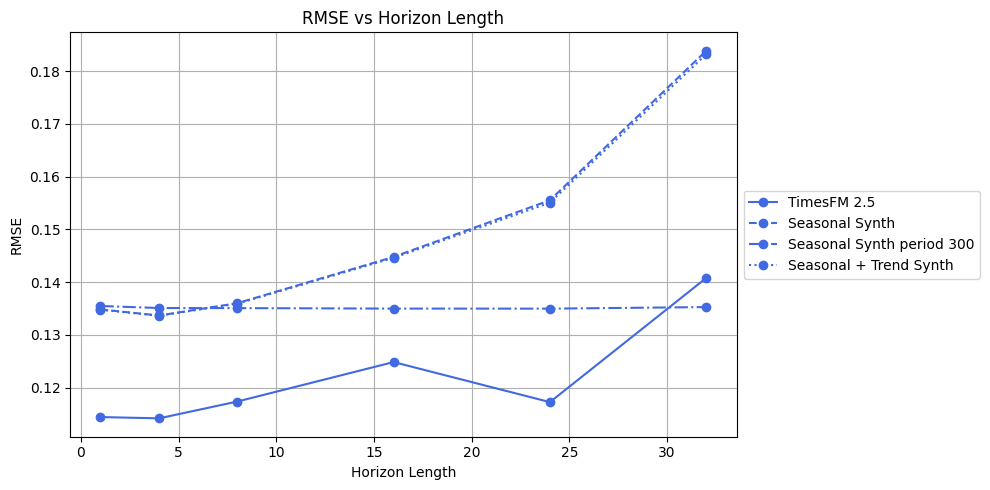

In [22]:
file_paths = [
    "results/plain_prediction/synth_timesfm2_5_results_2026-03-20.json",
    "results/seasonal_decomposition/seasonal_synth_metrics_results_2026-03-20.json",
    "results/seasonal_decomposition/seasonal_synth_metrics_results_period300.json",
    "results/seasonal_decomposition/both_synth_metrics_results_2026-03-20.json"
]
labels = [
    "TimesFM 2.5",
    "Seasonal Synth",
    "Seasonal Synth period 300",
    "Seasonal + Trend Synth"
]

linestyles = ['-', '--', '-.', ':']

plt.figure(figsize=(10, 5))
for path, label, linestyle in zip(file_paths, labels, linestyles):
    with open(path, 'r') as f:
        data = json.load(f)
    
    horizons = []
    rmses = []
    
    for exp in data["experiments"]:
        horizons.append(exp["horizon"])
        rmses.append(exp["metrics"]["TimesFM 2.5"]["RMSE"])
    
    # Sort by horizon
    horizons, rmses = zip(*sorted(zip(horizons, rmses)))
    
    plt.plot(horizons, rmses, linestyle=linestyle, marker='o', label=label, color="royalblue")

plt.xlabel("Horizon Length")
plt.ylabel("RMSE")
plt.title("RMSE vs Horizon Length")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

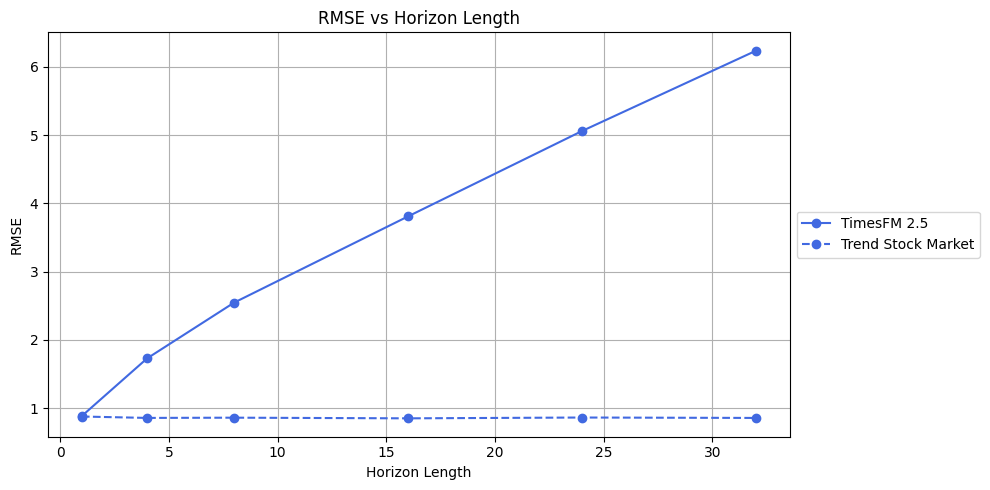

In [3]:
file_paths = [
    "results/plain_prediction/timesfm2_5_results_2026-03-20.json",
    "results/seasonal_decomposition/trend_diff_metrics_results_2026-03-20.json"
]
labels = [
    "TimesFM 2.5",
    "Trend Stock Market"
]

linestyles = ['-', '--', ':']

plt.figure(figsize=(10, 5))
for path, label, linestyle in zip(file_paths, labels, linestyles):
    with open(path, 'r') as f:
        data = json.load(f)
    
    horizons = []
    rmses = []
    
    for exp in data["experiments"]:
        horizons.append(exp["horizon"])
        rmses.append(exp["metrics"]["TimesFM 2.5"]["RMSE"])
    
    # Sort by horizon
    horizons, rmses = zip(*sorted(zip(horizons, rmses)))
    
    plt.plot(horizons, rmses, linestyle=linestyle, marker='o', label=label, color="royalblue")

plt.xlabel("Horizon Length")
plt.ylabel("RMSE")
plt.title("RMSE vs Horizon Length")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

### Detailed graphs
#### Synthetic dataset

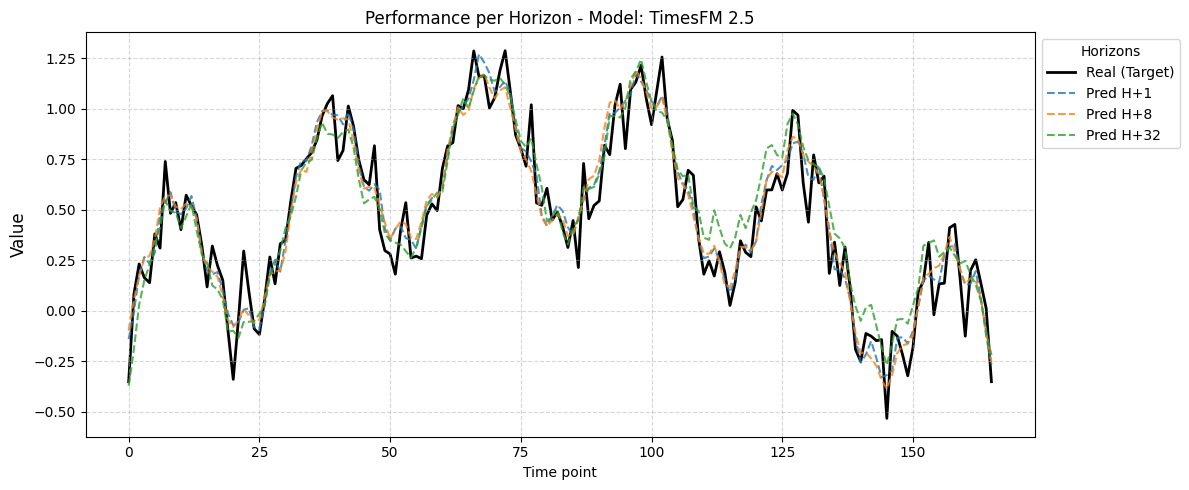

In [23]:
with open('results/plain_prediction/synth_timesfm2_5_results_2026-03-20.json', 'r') as f:
    data = json.load(f)

df = extract_experiment_data(data)
plot_model_multi_horizon(df, model_name="TimesFM 2.5", horizons_to_plot=[1, 8, 32])

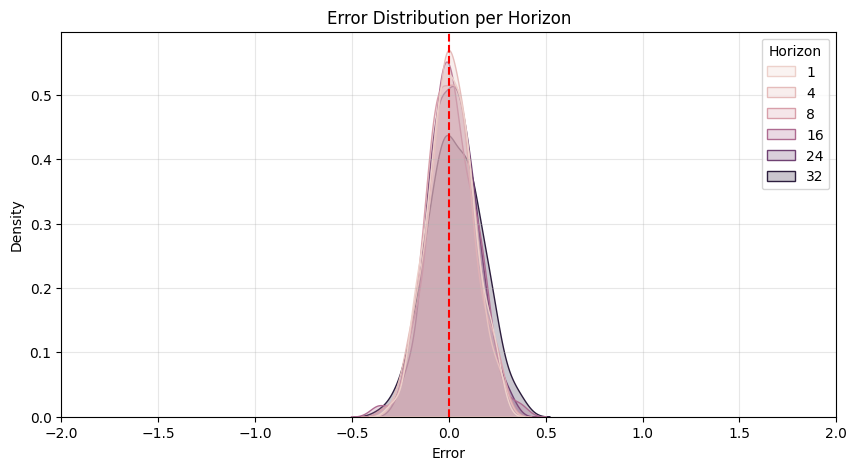

In [24]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="Error", hue="Horizon", fill=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Error Distribution per Horizon')
plt.xlim([-2.0, 2.0])
plt.grid(True, alpha=0.3)
plt.show()

#### Stock market dataset

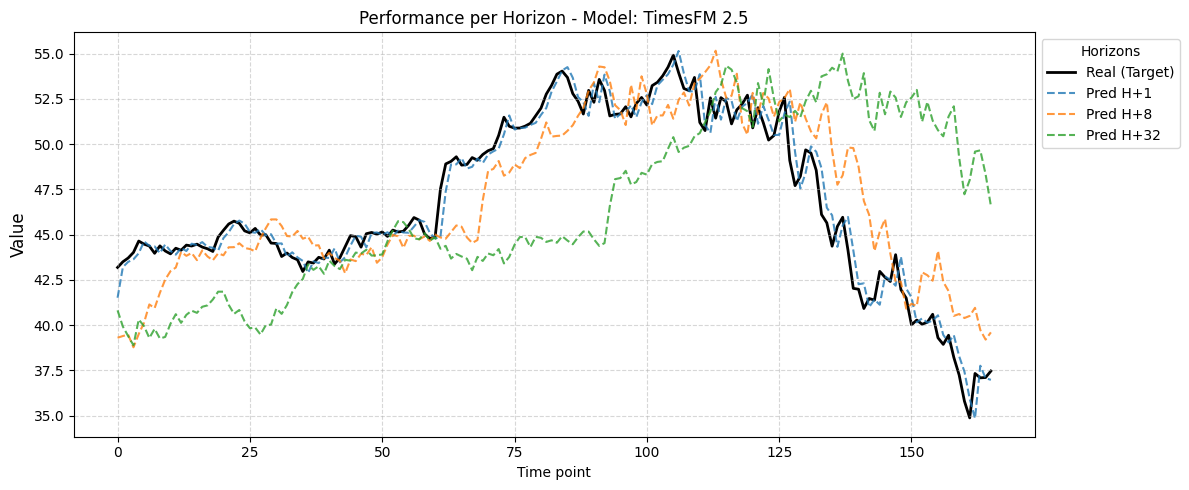

In [7]:
with open('results/plain_prediction/timesfm2_5_results_2026-03-20.json', 'r') as f:
    data = json.load(f)

df = extract_experiment_data(data)
plot_model_multi_horizon(df, model_name="TimesFM 2.5", horizons_to_plot=[1, 8, 32])

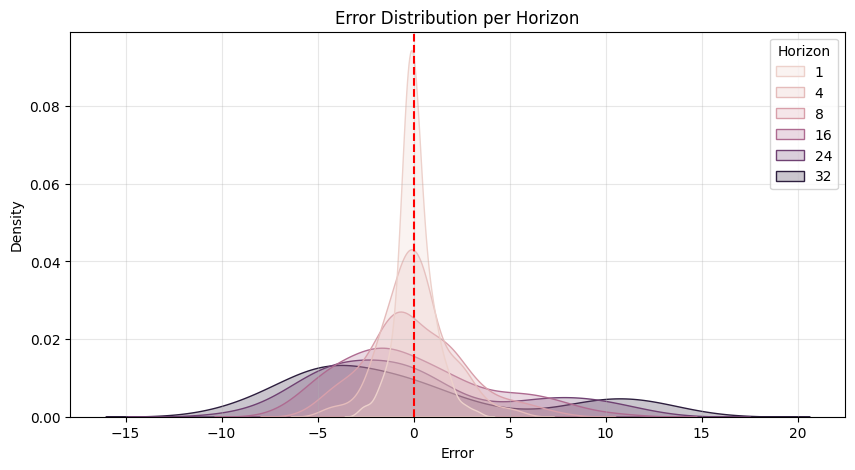

In [8]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x="Error", hue="Horizon", fill=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Error Distribution per Horizon')
plt.grid(True, alpha=0.3)
plt.show()

## Electricity demand
### Daily data

In [16]:
# Define hyperparameters 
context_length = [256]
horizon_length = range(1,8)
max_h = max(horizon_length)
freq_type = 0
is_real_data = True
file_path = 'input_diario_d.parquet'


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


results = {
    "freq_type": freq_type,
    "is_real_data": "demand",
    "experiments": []
}

for c in context_length:
    for h in horizon_length:
        print(f"Evaluating Case: Context={c}, Horizon={h}")
        train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_demand_data(file_path=file_path,
                                                                                         context_len=c,
                                                                                         horizon_len=h,
                                                                                         max_horizon_len=max_h,
                                                                                         freq_type=freq_type
                                                                                         )

        metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler)

        results["experiments"].append({
            "context_length": c,
            "horizon": h,
            "metrics": metrics
        })

date_str = datetime.now().strftime("%Y-%m-%d")
file_name = f"demand_timesfm2_5_results_{date_str}.json"

output_dir = RESULTS_DIRS["plain_prediction"]
file_path = os.path.join(output_dir, file_name)

with open(file_path, "w") as f:
    json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=256, Horizon=1
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 40379.5766
Inference time: 10.4155 seconds

Evaluating Case: Context=256, Horizon=2
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 53426.9589
Inference time: 10.6862 seconds

Evaluating Case: Context=256, Horizon=3
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 59475.8159
Inference time: 11.8645 seconds

Evaluating Case: Context=256, Horizon=4
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 62706.8537
Inference time: 11.4547 seconds

Evaluating Case: Context=256, Horizon=5
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 63877.6450
Inference time: 12.4224 seconds

Evaluati

#### Seasonal decomposition (automatic period detection)

In [18]:
# Define hyperparameters 
context_length = [256]
horizon_length = range(1,8)
max_h = max(horizon_length)
freq_type = 0
is_real_data = True
decompose_method = "seasonal"
file_path = 'input_diario_d.parquet'


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


results = {
    "freq_type": freq_type,
    "is_real_data": "demand",
    "experiments": []
}

for c in context_length:
    for h in horizon_length:
        print(f"Evaluating Case: Context={c}, Horizon={h}")
        train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_demand_data(file_path=file_path,
                                                                                         context_len=c,
                                                                                         horizon_len=h,
                                                                                         max_horizon_len=max_h,
                                                                                         freq_type=freq_type,
                                                                                         decompose=decompose_method,
                                                                                         period="auto"
                                                                                         )

        metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler)

        results["experiments"].append({
            "context_length": c,
            "horizon": h,
            "metrics": metrics
        })

date_str = datetime.now().strftime("%Y-%m-%d")
file_name = f"demand_{decompose_method}_timesfm2_5_results_{date_str}.json"

output_dir = RESULTS_DIRS["seasonal_decomposition"]
file_path = os.path.join(output_dir, file_name)

with open(file_path, "w") as f:
    json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=256, Horizon=1
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 39160.3783
Inference time: 10.3311 seconds

Evaluating Case: Context=256, Horizon=2
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 52080.0639
Inference time: 10.9320 seconds

Evaluating Case: Context=256, Horizon=3
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 58551.7546
Inference time: 11.9791 seconds

Evaluating Case: Context=256, Horizon=4
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 62108.7768
Inference time: 13.5121 seconds

Evaluating Case: Context=256, Horizon=5
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using 

In [19]:
# Define hyperparameters 
context_length = [256]
horizon_length = range(1,8)
max_h = max(horizon_length)
freq_type = 0
is_real_data = True
decompose_method = "both"
file_path = 'input_diario_d.parquet'


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


results = {
    "freq_type": freq_type,
    "is_real_data": "demand",
    "experiments": []
}

for c in context_length:
    for h in horizon_length:
        print(f"Evaluating Case: Context={c}, Horizon={h}")
        train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_demand_data(file_path=file_path,
                                                                                         context_len=c,
                                                                                         horizon_len=h,
                                                                                         max_horizon_len=max_h,
                                                                                         freq_type=freq_type,
                                                                                         decompose=decompose_method,
                                                                                         period="auto"
                                                                                         )

        metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler)

        results["experiments"].append({
            "context_length": c,
            "horizon": h,
            "metrics": metrics
        })

date_str = datetime.now().strftime("%Y-%m-%d")
file_name = f"demand_{decompose_method}_timesfm2_5_results_{date_str}.json"

output_dir = RESULTS_DIRS["seasonal_decomposition"]
file_path = os.path.join(output_dir, file_name)

with open(file_path, "w") as f:
    json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=256, Horizon=1
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 38781.6897
Inference time: 33.3781 seconds

Evaluating Case: Context=256, Horizon=2
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 51859.5321
Inference time: 29.2563 seconds

Evaluating Case: Context=256, Horizon=3
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 58452.1126
Inference time: 16.1679 seconds

Evaluating Case: Context=256, Horizon=4
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using frequency type: 0
Validation Metrics
RMSE: 62085.1173
Inference time: 15.1166 seconds

Evaluating Case: Context=256, Horizon=5
Detected Period: 7
Created datasets:
- Training samples: 901
- Test samples: 29
- Using 

#### Results comparison

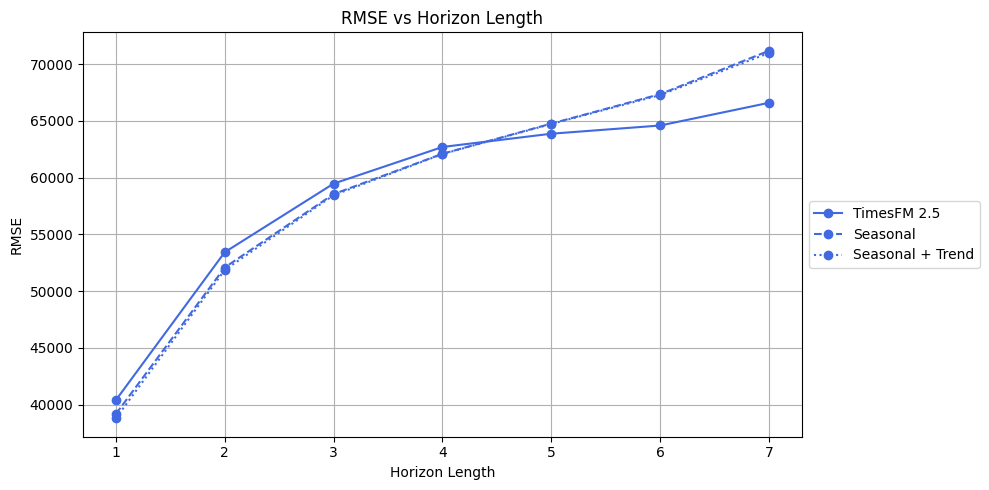

In [9]:
file_paths = [
    "results/plain_prediction/demand_timesfm2_5_results_2026-03-20.json",
    "results/seasonal_decomposition/demand_seasonal_timesfm2_5_results_2026-03-20.json",
    "results/seasonal_decomposition/demand_both_timesfm2_5_results_2026-03-20.json"
]
labels = [
    "TimesFM 2.5",
    "Seasonal",
    "Seasonal + Trend"
]

linestyles = ['-', '--', ':']

plt.figure(figsize=(10, 5))
for path, label, linestyle in zip(file_paths, labels, linestyles):
    with open(path, 'r') as f:
        data = json.load(f)
    
    horizons = []
    rmses = []
    
    for exp in data["experiments"]:
        horizons.append(exp["horizon"])
        rmses.append(exp["metrics"]["TimesFM 2.5"]["RMSE"])
    
    # Sort by horizon
    horizons, rmses = zip(*sorted(zip(horizons, rmses)))
    
    plt.plot(horizons, rmses, linestyle=linestyle, marker='o', label=label, color="royalblue")

plt.xlabel("Horizon Length")
plt.ylabel("RMSE")
plt.title("RMSE vs Horizon Length")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

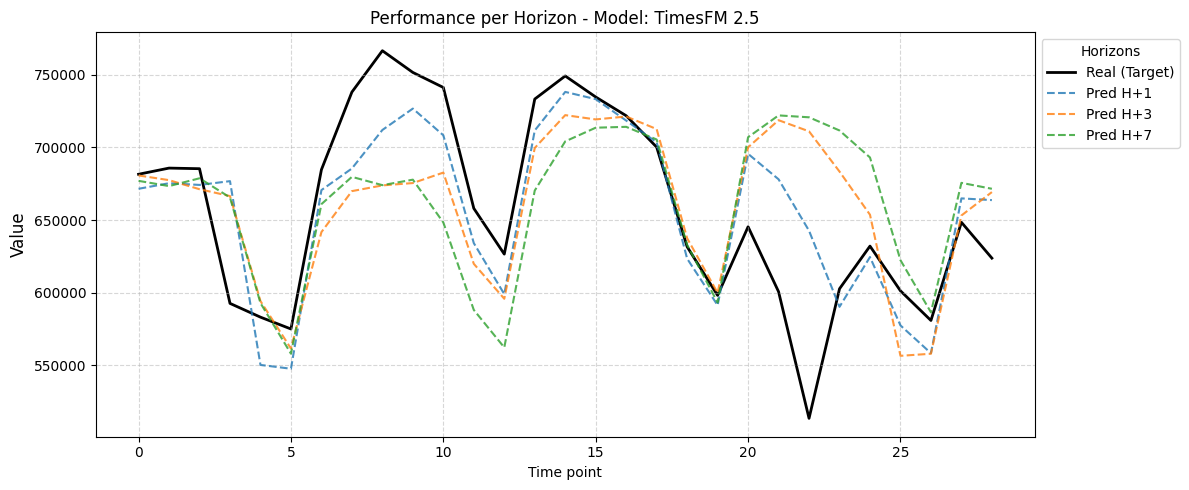

In [10]:
with open('results/plain_prediction/demand_timesfm2_5_results_2026-03-20.json', 'r') as f:
    data = json.load(f)
df = extract_experiment_data(data)

plot_model_multi_horizon(df, model_name="TimesFM 2.5", horizons_to_plot=[1, 3, 7])

### Hourly data

In [ ]:
# The following is run over the first 4380 points recorded, that is, half 
# a year to avoid excessive running times
context_length = [288]
horizon_length = [12, 24, 36, 48]
max_h = max(horizon_length)
freq_type = 0
is_real_data = True
file_path = 'input_horario_d.parquet'


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


results = {
    "freq_type": freq_type,
    "is_real_data": "demand",
    "experiments": []
}

for c in context_length:
    for h in horizon_length:
        print(f"Evaluating Case: Context={c}, Horizon={h}")
        train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_demand_data(file_path=file_path,
                                                                                         context_len=c,
                                                                                         horizon_len=h,
                                                                                         max_horizon_len=max_h,
                                                                                         freq_type=freq_type
                                                                                         )

        metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler)

        results["experiments"].append({
            "context_length": c,
            "horizon": h,
            "metrics": metrics
        })

date_str = datetime.now().strftime("%Y-%m-%d")
file_name = f"hourlydemand_timesfm2_5_results_{date_str}.json"

output_dir = RESULTS_DIRS["plain_prediction"]
file_path = os.path.join(output_dir, file_name)

with open(file_path, "w") as f:
    json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=288, Horizon=12
Created datasets:
- Training samples: 2353
- Test samples: 337
- Using frequency type: 0
Validation Metrics
RMSE: 1129.2336
Inference time: 179.5566 seconds

Evaluating Case: Context=288, Horizon=24
Created datasets:
- Training samples: 2353
- Test samples: 337
- Using frequency type: 0
Validation Metrics
RMSE: 1417.0394
Inference time: 152.0077 seconds

Evaluating Case: Context=288, Horizon=36
Created datasets:
- Training samples: 2353
- Test samples: 337
- Using frequency type: 0
Validation Metrics
RMSE: 1746.1037
Inference time: 149.4614 seconds

Evaluating Case: Context=288, Horizon=48
Created datasets:
- Training samples: 2353
- Test samples: 337
- Using frequency type: 0
Validation Metrics
RMSE: 1751.7415
Inference time: 147.3718 seconds



#### Seasonal decomposition (automatic period detection)

In [5]:
# Define hyperparameters 
context_length = [288]
horizon_length = [12, 24, 36, 48]
max_h = max(horizon_length)
freq_type = 0
is_real_data = True
decompose_method = "seasonal"
file_path = 'input_horario_d.parquet'


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


results = {
    "freq_type": freq_type,
    "is_real_data": "demand",
    "experiments": []
}

for c in context_length:
    for h in horizon_length:
        print(f"Evaluating Case: Context={c}, Horizon={h}")
        train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_demand_data(file_path=file_path,
                                                                                         context_len=c,
                                                                                         horizon_len=h,
                                                                                         max_horizon_len=max_h,
                                                                                         freq_type=freq_type,
                                                                                         decompose=decompose_method,
                                                                                         period="auto"
                                                                                         )

        metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler)

        results["experiments"].append({
            "context_length": c,
            "horizon": h,
            "metrics": metrics
        })

date_str = datetime.now().strftime("%Y-%m-%d")
file_name = f"hourlydemand_{decompose_method}_timesfm2_5_results_{date_str}.json"

output_dir = RESULTS_DIRS["seasonal_decomposition"]
file_path = os.path.join(output_dir, file_name)

with open(file_path, "w") as f:
    json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=288, Horizon=12
Detected Period: 168
Created datasets:
- Training samples: 2353
- Test samples: 337
- Using frequency type: 0
Validation Metrics
RMSE: 900.6074
Inference time: 150.4068 seconds

Evaluating Case: Context=288, Horizon=24
Detected Period: 168
Created datasets:
- Training samples: 2353
- Test samples: 337
- Using frequency type: 0
Validation Metrics
RMSE: 1091.8915
Inference time: 152.9888 seconds

Evaluating Case: Context=288, Horizon=36
Detected Period: 168
Created datasets:
- Training samples: 2353
- Test samples: 337
- Using frequency type: 0
Validation Metrics
RMSE: 1480.7967
Inference time: 149.1131 seconds

Evaluating Case: Context=288, Horizon=48
Detected Period: 168
Created datasets:
- Training samples: 2353
- Test samples: 337
- Using frequency type: 0
Validation Metrics
RMSE: 1609.6351
Inference time: 148.4609 seconds



In [4]:
# Define hyperparameters 
context_length = [288]
horizon_length = [12, 24, 36, 48]
max_h = max(horizon_length)
freq_type = 0
is_real_data = True
decompose_method = "both"
file_path = 'input_horario_d.parquet'


# Initialize model TimesFM 2.5
model_tsfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

model_tsfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        force_flip_invariance=True,
        infer_is_positive=True,
    )
)


results = {
    "freq_type": freq_type,
    "is_real_data": "demand",
    "experiments": []
}

for c in context_length:
    for h in horizon_length:
        print(f"Evaluating Case: Context={c}, Horizon={h}")
        train_dataset, test_dataset, scaler, seasonal_comp, train_size = get_demand_data(file_path=file_path,
                                                                                         context_len=c,
                                                                                         horizon_len=h,
                                                                                         max_horizon_len=max_h,
                                                                                         freq_type=freq_type,
                                                                                         decompose=decompose_method,
                                                                                         period="auto"
                                                                                         )

        metrics = get_timesfm_metrics(model_tsfm, test_dataset, scaler)

        results["experiments"].append({
            "context_length": c,
            "horizon": h,
            "metrics": metrics
        })

date_str = datetime.now().strftime("%Y-%m-%d")
file_name = f"hourlydemand_{decompose_method}_timesfm2_5_results_{date_str}.json"

output_dir = RESULTS_DIRS["seasonal_decomposition"]
file_path = os.path.join(output_dir, file_name)

with open(file_path, "w") as f:
    json.dump(results, f, indent=4)

Downloaded.
Evaluating Case: Context=288, Horizon=12
Detected Period: 168
Created datasets:
- Training samples: 2353
- Test samples: 337
- Using frequency type: 0
Validation Metrics
RMSE: 902.1600
Inference time: 143.3159 seconds

Evaluating Case: Context=288, Horizon=24
Detected Period: 168
Created datasets:
- Training samples: 2353
- Test samples: 337
- Using frequency type: 0
Validation Metrics
RMSE: 1098.3681
Inference time: 133.6049 seconds

Evaluating Case: Context=288, Horizon=36
Detected Period: 168
Created datasets:
- Training samples: 2353
- Test samples: 337
- Using frequency type: 0
Validation Metrics
RMSE: 1490.2016
Inference time: 169.5428 seconds

Evaluating Case: Context=288, Horizon=48
Detected Period: 168
Created datasets:
- Training samples: 2353
- Test samples: 337
- Using frequency type: 0
Validation Metrics
RMSE: 1623.9761
Inference time: 155.1189 seconds



#### Results comparison

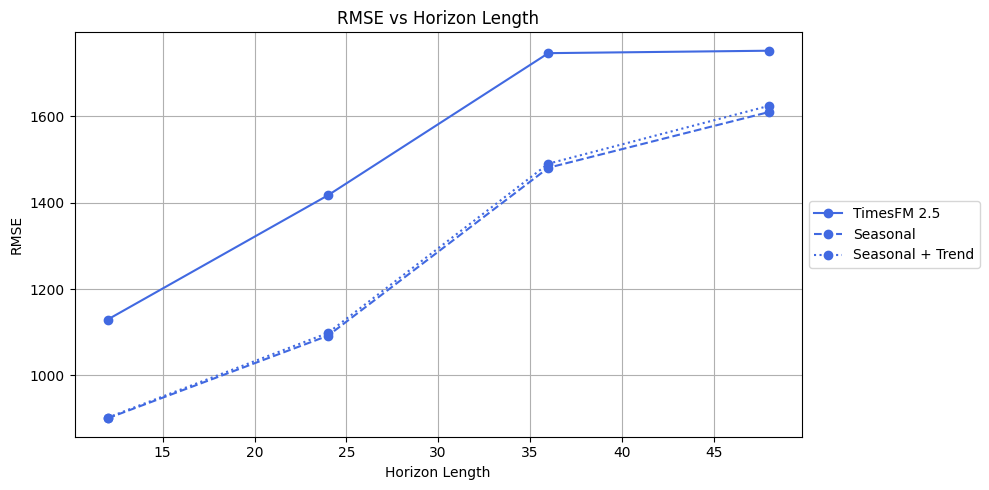

In [11]:
file_paths = [
    "results/plain_prediction/hourlydemand_timesfm2_5_results_2026-03-20.json",
    "results/seasonal_decomposition/hourlydemand_seasonal_timesfm2_5_results_2026-03-20.json",
    "results/seasonal_decomposition/hourlydemand_both_timesfm2_5_results_2026-03-20.json"
]
labels = [
    "TimesFM 2.5",
    "Seasonal",
    "Seasonal + Trend"
]

linestyles = ['-', '--', ':']

plt.figure(figsize=(10, 5))
for path, label, linestyle in zip(file_paths, labels, linestyles):
    with open(path, 'r') as f:
        data = json.load(f)
    
    horizons = []
    rmses = []
    
    for exp in data["experiments"]:
        horizons.append(exp["horizon"])
        rmses.append(exp["metrics"]["TimesFM 2.5"]["RMSE"])
    
    # Sort by horizon
    horizons, rmses = zip(*sorted(zip(horizons, rmses)))
    
    plt.plot(horizons, rmses, linestyle=linestyle, marker='o', label=label, color="royalblue")

plt.xlabel("Horizon Length")
plt.ylabel("RMSE")
plt.title("RMSE vs Horizon Length")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

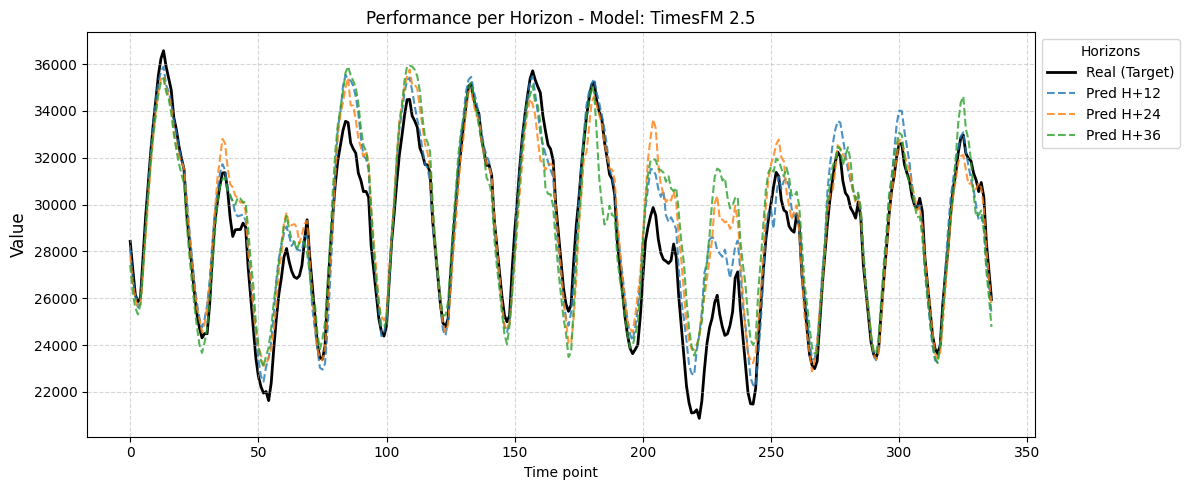

In [12]:
with open('results/plain_prediction/hourlydemand_timesfm2_5_results_2026-03-20.json', 'r') as f:
    data = json.load(f)
df = extract_experiment_data(data)

plot_model_multi_horizon(df, model_name="TimesFM 2.5", horizons_to_plot=[12, 24, 36])